
# 06 PySAL, libpysal & esda: Is Land Value Actually Clustered, or Just Random?

Everything so far has answered geometric questions ("do these overlap," "what's nearby"). This notebook
answers a genuinely different kind of question: **statistical** questions about patterns across many
parcels at once specifically, the question at the heart of the valuation-modeling feature: *is high
land value clustered in certain areas (near infrastructure, in certain neighborhoods), or is it randomly
scattered?* If it's clustered, that clustering itself becomes a powerful input feature for a valuation
model. If it's random, you'd be wasting effort building location-based features that don't predict
anything.

## What "PySAL" actually refers to

PySAL is really an umbrella project made of several smaller packages. The two you'll use directly:

- **`libpysal`** builds **spatial weights matrices**: a formal way of saying "which parcels count as
  each other's neighbors, and how strongly." Nothing else in this notebook works without this step.
- **`esda`** (Exploratory Spatial Data Analysis) the actual statistics built on top of those weights,
  most importantly **Moran's I**, the standard measure of spatial autocorrelation.

## Step 1: build a spatial weights matrix

There's more than one valid way to define "neighbor." For irregularly-shaped, unevenly-spaced land
parcels (as opposed to a tidy grid), **K-nearest-neighbors (KNN) weights** "each parcel's neighbors are
its 5 geometrically closest parcels" is usually the most practical choice, and the one used below.


<Axes: >

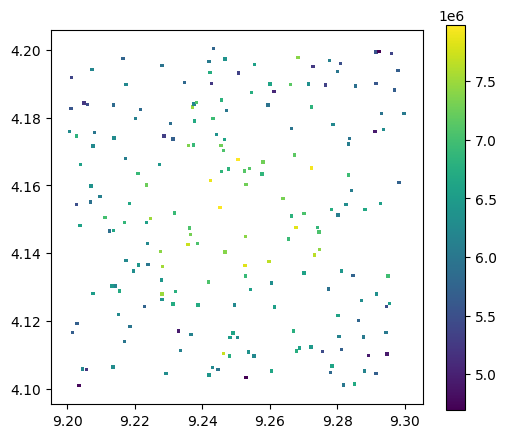

In [1]:

import geopandas as gpd
import numpy as np
from shapely.geometry import box
from libpysal.weights import KNN
from esda.moran import Moran

# Build a synthetic dataset: 200 parcels, with price artificially correlated with
# distance from a fixed "town center" point, to simulate a realistic clustering pattern
np.random.seed(7)
n = 200
xs = np.random.uniform(9.20, 9.30, n)
ys = np.random.uniform(4.10, 4.20, n)

town_center_x, town_center_y = 9.25, 4.15
distance_from_center = np.sqrt((xs - town_center_x)**2 + (ys - town_center_y)**2)

# Price decreases with distance from center, plus some random noise a deliberately clustered pattern
base_price = 8_000_000
price = base_price - (distance_from_center * 40_000_000) + np.random.normal(0, 500_000, n)
price = np.clip(price, 500_000, None)

parcels = gpd.GeoDataFrame({
    "parcel_id": [f"PARC-{i:04d}" for i in range(n)],
    "price_xaf": price,
    "geometry": [box(x, y, x + 0.001, y + 0.001) for x, y in zip(xs, ys)],
}, crs="EPSG:4326")

parcels.plot(column="price_xaf", cmap="viridis", legend=True, figsize=(6, 5), markersize=20)


In [2]:

# Build KNN spatial weights based on each parcel's centroid
coords = np.array(list(zip(parcels.geometry.centroid.x, parcels.geometry.centroid.y)))
w = KNN.from_array(coords, k=5)
w.transform = "r"  # row-standardize the weights standard practice before running Moran's I

print(f"Each parcel has {w.mean_neighbors:.0f} neighbors on average (should be 5, by construction)")


Each parcel has 5 neighbors on average (should be 5, by construction)


C:\Users\GROUP\AppData\Local\Temp\ipykernel_13380\1947954588.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  coords = np.array(list(zip(parcels.geometry.centroid.x, parcels.geometry.centroid.y)))



## Step 2: Moran's I is this pattern clustered, or could it be random?

Moran's I returns a value roughly between -1 and +1:

- **Close to +1**: strong positive spatial autocorrelation similar values cluster together (high
  prices near high prices, low near low). This is what you'd expect for real land value, since location
  genuinely drives value.
- **Close to 0**: no spatial pattern essentially random with respect to location.
- **Close to -1**: a checkerboard pattern high values surrounded by low values, unusual in real
  economic data.

Alongside the Moran's I value itself, always look at the **p-value** it tells you whether the pattern
is statistically unlikely to have arisen by chance, not just what the number happens to be.


In [3]:

moran = Moran(parcels["price_xaf"].values, w)

print(f"Moran's I: {moran.I:.4f}")
print(f"p-value:   {moran.p_sim:.4f}")

if moran.p_sim < 0.05 and moran.I > 0:
    print("\nInterpretation: statistically significant positive spatial autocorrelation.")
    print("Land price IS meaningfully clustered by location in this data proximity-based")
    print("features (e.g. distance to town center, distance to infrastructure) are worth")
    print("including in a valuation model.")
else:
    print("\nInterpretation: no strong evidence of spatial clustering in this data.")


Moran's I: 0.4394
p-value:   0.0010

Interpretation: statistically significant positive spatial autocorrelation.
Land price IS meaningfully clustered by location in this data proximity-based
features (e.g. distance to town center, distance to infrastructure) are worth
including in a valuation model.



## Local clustering which specific parcels are the "hot spots"?

Moran's I gives you one global number for the whole dataset. Often more useful in practice: **Local
Indicators of Spatial Association (LISA)**, which flag *which specific parcels* sit in high-value
clusters, low-value clusters, or are unusual outliers relative to their neighbors directly useful for
a "which areas should this land banking company prioritize acquiring in" kind of business question.


In [4]:

from esda.moran import Moran_Local

lisa = Moran_Local(parcels["price_xaf"].values, w)

# lisa.q classifies each parcel into one of four quadrants:
# 1 = High-High (high value surrounded by high value a genuine "hot spot")
# 2 = Low-High  (low value surrounded by high value a possible undervalued opportunity)
# 3 = Low-Low   (low value surrounded by low value a "cold spot")
# 4 = High-Low  (high value surrounded by low value an outlier worth double-checking)

quadrant_labels = {1: "High-High (hot spot)", 2: "Low-High (potential opportunity)",
                    3: "Low-Low (cold spot)", 4: "High-Low (outlier)"}

parcels["cluster_type"] = [quadrant_labels[q] for q in lisa.q]
# Only flag clusters where the local result is itself statistically significant
parcels["significant"] = lisa.p_sim < 0.05

parcels[parcels["significant"]][["parcel_id", "price_xaf", "cluster_type"]].head(10)


,parcel_id,price_xaf,cluster_type
2,PARC-0002,6.365335e+06,Low-High (potential opportunity)
6,PARC-0006,7.983653e+06,High-High (hot spot)
11,PARC-0011,5.505411e+06,Low-Low (cold spot)
12,PARC-0012,7.055338e+06,High-High (hot spot)
15,PARC-0015,5.560452e+06,Low-Low (cold spot)
16,PARC-0016,5.831061e+06,Low-Low (cold spot)
17,PARC-0017,6.841787e+06,High-High (hot spot)
18,PARC-0018,6.281722e+06,Low-Low (cold spot)
20,PARC-0020,6.311119e+06,Low-High (potential opportunity)
24,PARC-0024,5.593403e+06,Low-Low (cold spot)


<Axes: >

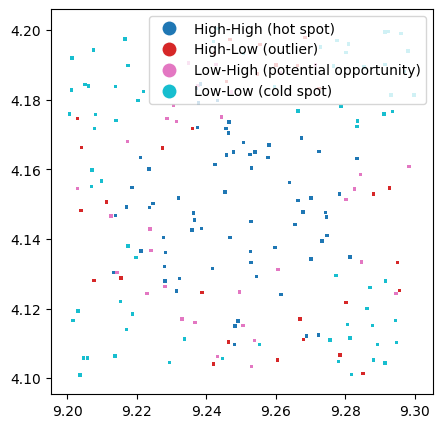

In [5]:

parcels.plot(column="cluster_type", categorical=True, legend=True, figsize=(6, 5), markersize=25)



That "Low-High" category is worth pausing on those are parcels priced low but surrounded by
higher-value neighbors. In a real product, that's exactly the kind of signal worth surfacing to a land
banking company as a **potential acquisition opportunity**, not just an academic statistic.

## Exercises

### Exercise 1
Rebuild the weights matrix using `k=10` instead of `k=5`. Does the Moran's I value change much? (It
shouldn't change dramatically for a genuinely clustered pattern like this one a sanity check that your
result isn't just an artifact of one arbitrary choice of `k`.)


In [6]:
# Your code here


#### Solution

In [6]:

w10 = KNN.from_array(coords, k=10)
w10.transform = "r"
moran_k10 = Moran(parcels["price_xaf"].values, w10)
print(f"Moran's I with k=5:  {moran.I:.4f}")
print(f"Moran's I with k=10: {moran_k10.I:.4f}")


Moran's I with k=5:  0.4394
Moran's I with k=10: 0.3712



### Exercise 2
Generate a second synthetic dataset where price is assigned **completely randomly**, with no
relationship to location at all. Run Moran's I on it and confirm the result looks meaningfully different
from the clustered dataset above this is the "negative control" that proves your pipeline is actually
detecting something real, not just always returning a high number regardless of input.


In [8]:
# Your code here


#### Solution

In [ ]:

np.random.seed(3)
random_price = np.random.uniform(500_000, 8_000_000, n)

moran_random = Moran(random_price, w)
print(f"Moran's I (random prices): {moran_random.I:.4f}")
print(f"p-value:                   {moran_random.p_sim:.4f}")
print("\nCompare this to the clustered result above this should be much closer to zero,")
print("and very likely not statistically significant.")


Moran's I (random prices): -0.0843
p-value:                   0.0210

Compare this to the clustered result above — this should be much closer to zero,
and very likely not statistically significant.



## What's next

You now have a way to turn "is this pattern real" into a defensible statistical answer genuinely
useful for the valuation-modeling feature specifically. The remaining gap: everything has lived in
memory so far. **`07_postgis_integration_psycopg2.ipynb`** covers persisting this data properly, in the
same PostgreSQL database your product's backend already uses.
